In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed_market/processed_EURUSD_H1_20200101_20260131.csv", index_col="time", parse_dates=["time"])

df.head()

,Open,High,Low,Close,Volume,TRIX_30_9,VWAP_D,ROC_10,RSI_14,ATRr_14,...,STOCHRSIk_14_14_3_3,ADX_14,DMP_14,DMN_14,STOCHk_14_3_3,STOCHh_14_3_3,LogRet_5h,LogRet_12h,LogRet_24h,Target_5h_TBM
time,,,,,,,,,,,,,,,,,,,,,
2020-01-07 22:00:00+00:00,1.11519,1.11534,1.11441,1.11476,1150,-0.000627,1.116562,-0.243405,37.577962,0.000995,...,45.404353,35.597813,0.001988,0.003742,25.178571,2.953582,0.000628,-0.001823,-0.003424,0.0
2020-01-07 23:00:00+00:00,1.11473,1.11543,1.11464,1.11541,2426,-0.001033,1.116489,-0.019720,43.262676,0.000980,...,62.526554,35.085621,0.001936,0.003474,32.098271,5.235909,-0.000565,-0.002415,-0.003692,2.0
2020-01-08 00:00:00+00:00,1.11540,1.11682,1.11526,1.11587,5297,-0.001396,1.115983,0.097777,46.945033,0.001021,...,74.697223,32.622108,0.003188,0.003226,37.633753,5.996888,-0.000852,-0.003762,-0.004068,1.0
2020-01-08 01:00:00+00:00,1.11587,1.11633,1.11549,1.11557,3900,-0.001729,1.115904,0.126553,44.898418,0.001009,...,88.270651,30.334560,0.002960,0.002996,44.152570,6.191039,-0.000493,-0.003205,-0.003439,2.0
2020-01-08 02:00:00+00:00,1.11558,1.11614,1.11531,1.11586,3508,-0.002024,1.115867,0.194848,47.290610,0.000996,...,95.293830,28.434208,0.002749,0.002962,50.015138,6.081317,-0.000663,-0.003052,-0.003897,1.0


In [19]:
for c in df.columns:
    print(f"{c}: {df[c].dtype}")

Open: float64
High: float64
Low: float64
Close: float64
Volume: int64
TRIX_30_9: float64
VWAP_D: float64
ROC_10: float64
RSI_14: float64
ATRr_14: float64
MFI_14: float64
EFI_13: float64
BBB_5_2.0_2.0: float64
BBP_5_2.0_2.0: float64
CCI_14_0.015: float64
TSI_13_25_13: float64
STOCHRSIk_14_14_3_3: float64
ADX_14: float64
DMP_14: float64
DMN_14: float64
STOCHk_14_3_3: float64
STOCHh_14_3_3: float64
LogRet_5h: float64
LogRet_12h: float64
LogRet_24h: float64
Target_5h_TBM: float64


### Correlation Between Indicators


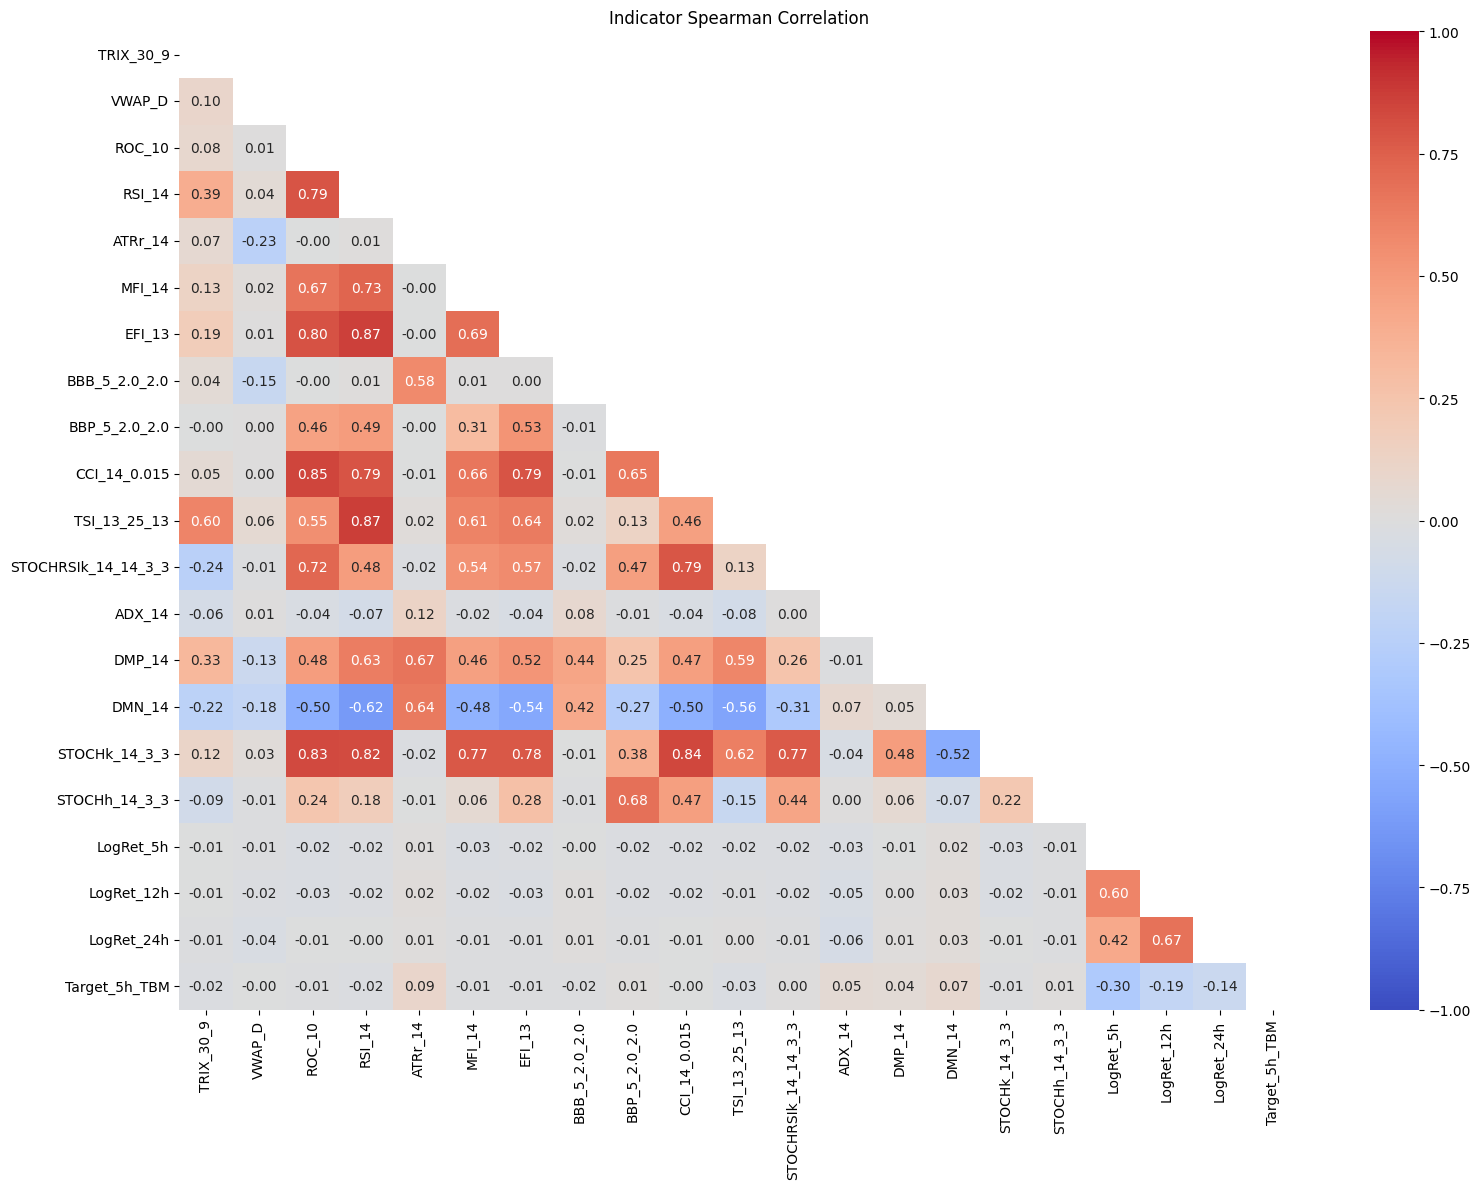

In [16]:
drop_cols = ["Open", "High", "Low", "Close", "Volume", "Target"]
indicator_cols = [col for col in df.columns if col not in drop_cols and col != "Time"]

plt.figure(figsize=(16, 12))

# compute Spearman correlation matrix for technical indicators
corr_matrix = df[indicator_cols].corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Indicator Spearman Correlation")
plt.tight_layout()
plt.show()
